In [1]:
import minigrid
import numpy as np
import gymnasium as gym
import causal_gym as cgym
import matplotlib.pyplot as plt

from causal_gym.envs import WindyMiniGridPCH
from causal_gym.core.wrappers import MiniGridActionRemapWrapper
from causal_gym.core import Task
from causal_gym.envs import WIND_DIST

In [2]:
SEED = 6458

def show_obs(img, name=None):
    plt.imshow(img)
    plt.axis('off')
    if name is not None:
        plt.tight_layout()
        fig = plt.gcf()
        fig.set_size_inches(8, 6)
        imgPath = f'env-{name}.png'
        fig.savefig(imgPath, dpi=800, bbox_inches='tight', pad_inches=0)
    plt.show()

### Empty World

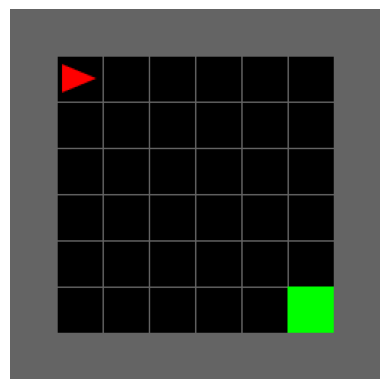

In [3]:
env = gym.make('MiniGrid-Empty-8x8-v0', max_episode_steps=70, agent_pov=False, render_mode='rgb_array', highlight=False)
_, info = env.reset(seed=SEED)
show_obs(env.render())

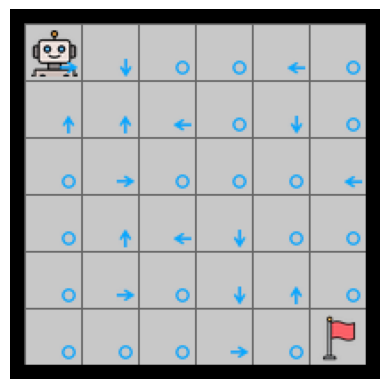

In [4]:
windy_env = MiniGridActionRemapWrapper(WindyMiniGridPCH(env=env, show_wind=True, task=Task(learning_regime='see')))
windy_env.reset(seed=SEED)
show_obs(windy_env.render())

3 -0.1


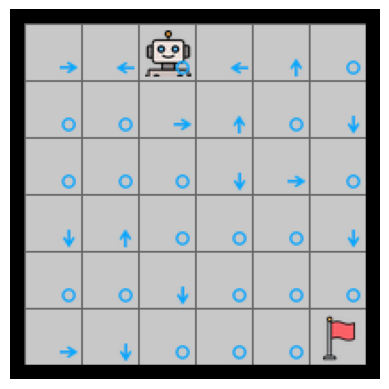

In [5]:
sp, r, term, trun, info = windy_env.see(bpolicy=lambda state, wind: 3)
a = info['natural_action']
print(a, r)
show_obs(windy_env.render())

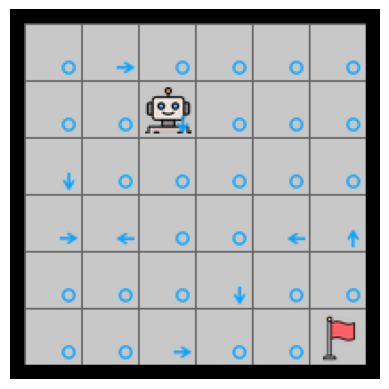

In [6]:
windy_env.agent_pos = (3,2)
windy_env.agent_dir = 2
windy_env.wind_dir = 1
show_obs(windy_env.render())

### LavaCross

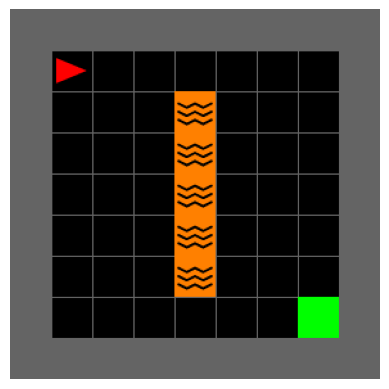

In [7]:
env = gym.make('Custom-LavaCrossing-easy-v0', max_episode_steps=70, agent_pov=False, render_mode='rgb_array', highlight=False, size=9)
_, info = env.reset(seed=SEED)
show_obs(env.render())

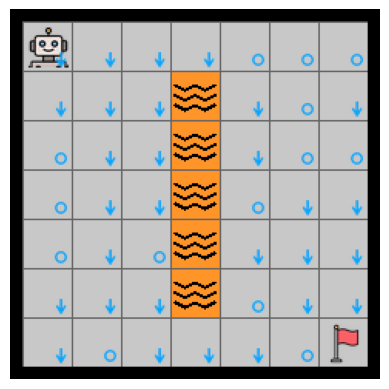

In [8]:
windy_env = MiniGridActionRemapWrapper(WindyMiniGridPCH(env=env, show_wind=True, wind_dist=WIND_DIST['Custom-LavaCrossing-easy-v0'], task=Task(learning_regime='cool')))
init_obs, info = windy_env.reset(seed=SEED)
show_obs(windy_env.render())

1 -0.1 False False


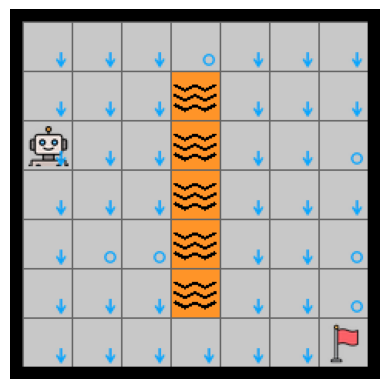

In [9]:
sp, r, term, trun, info = windy_env.see(bpolicy=lambda state, wind: 1)
print(info['natural_action'], r, term, trun)
show_obs(windy_env.render())

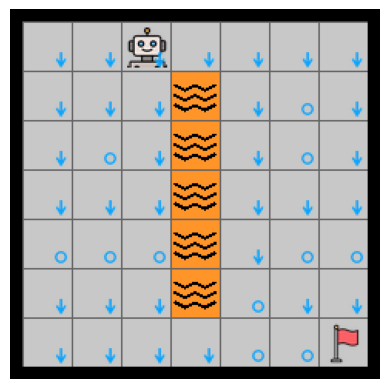

In [10]:
# a, sp, r, term, trun, info = windy_env.see(bpolicy=lambda state, wind: 1)
# print(a, r, term, trun)
# (3, 1) 3 -0.1 (4, 1) 0 0
# (3, 1) 3 -0.1 (4, 1) 1 0.8
# (3, 1) 3 -0.1 (3, 1) 2 0
# (3, 1) 3 -0.1 (4, 1) 3 0
# (3, 1) 3 -0.1 (4, 1) 4 0.2
windy_env.agent_pos = (3,1)
windy_env.agent_dir = 0
windy_env.wind_dir = 1
show_obs(windy_env.render())

(4, 2) -1.1


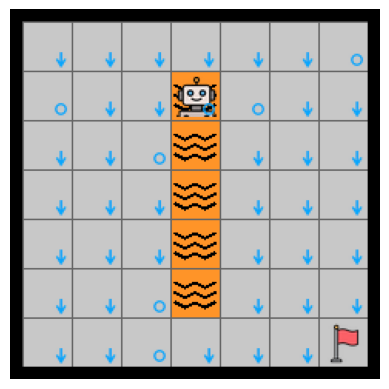

In [11]:
sp, r, _, _, _ = windy_env.do(lambda x: 3)
print(sp, r)
show_obs(windy_env.render())

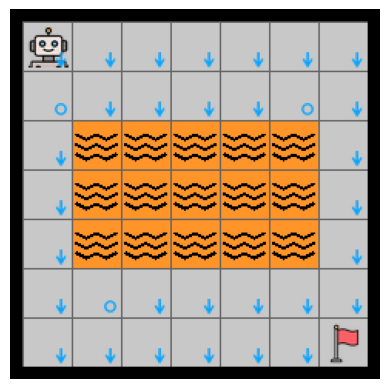

In [12]:
env = gym.make('Custom-LavaCrossing-hard-v0', max_episode_steps=70, agent_pov=False, render_mode='rgb_array', highlight=False, size=9)
_, info = env.reset(seed=SEED)
windy_env = MiniGridActionRemapWrapper(WindyMiniGridPCH(env=env, show_wind=True, wind_dist=WIND_DIST['Custom-LavaCrossing-hard-v0']))
init_obs, info = windy_env.reset(seed=SEED)
show_obs(windy_env.render())

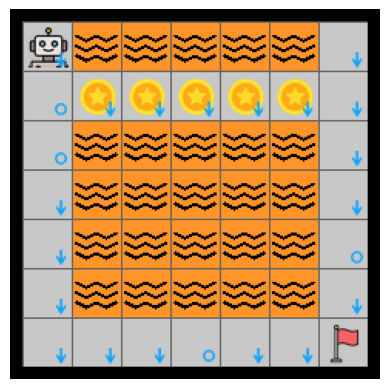

In [13]:
env = gym.make('Custom-LavaCrossing-extreme-v0', max_episode_steps=70, agent_pov=False, render_mode='rgb_array', highlight=False, size=9)
_, info = env.reset(seed=SEED)
windy_env = MiniGridActionRemapWrapper(WindyMiniGridPCH(env=env, show_wind=True, wind_dist=WIND_DIST['Custom-LavaCrossing-extreme-v0']))
init_obs, info = windy_env.reset(seed=SEED)
show_obs(windy_env.render())

(1, 3) -0.1


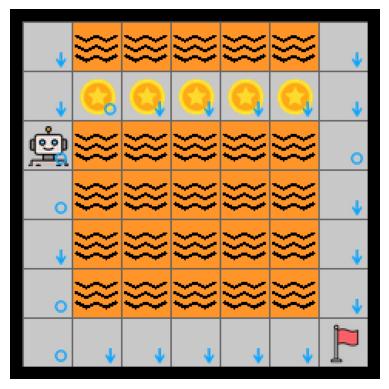

In [15]:
sp, r, _, _, _ = windy_env.do(lambda x: 1)
print(sp, r)
show_obs(windy_env.render())

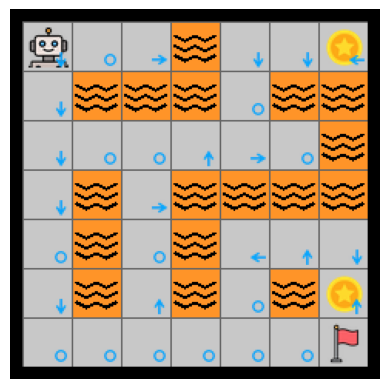

In [16]:
env = gym.make('Custom-LavaCrossing-maze-v0', max_episode_steps=70, agent_pov=False, render_mode='rgb_array', highlight=False, size=9)
_, info = env.reset(seed=SEED)
windy_env = MiniGridActionRemapWrapper(WindyMiniGridPCH(env=env, show_wind=True, wind_dist=WIND_DIST['Custom-LavaCrossing-maze-v0']))
init_obs, info = windy_env.reset(seed=SEED)
show_obs(windy_env.render())

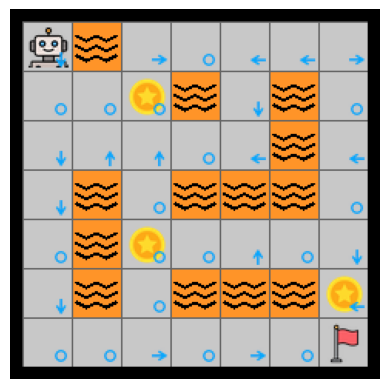

In [17]:
env = gym.make('Custom-LavaCrossing-maze-complex-v0', max_episode_steps=70, agent_pov=False, render_mode='rgb_array', highlight=False, size=9)
_, info = env.reset(seed=SEED)
windy_env = MiniGridActionRemapWrapper(WindyMiniGridPCH(env=env, show_wind=True, wind_dist=WIND_DIST['Custom-LavaCrossing-maze-v0']))
init_obs, info = windy_env.reset(seed=SEED)
show_obs(windy_env.render())

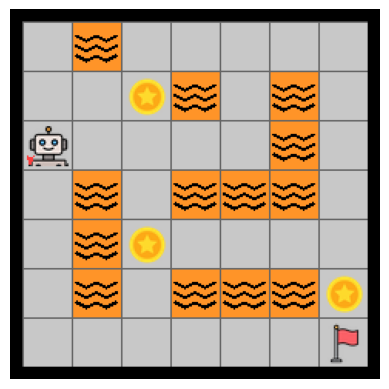

In [19]:
windy_env.do(lambda x: 1)
show_obs(windy_env.render(action_todo=1, show_policy=True, show_wind=False))

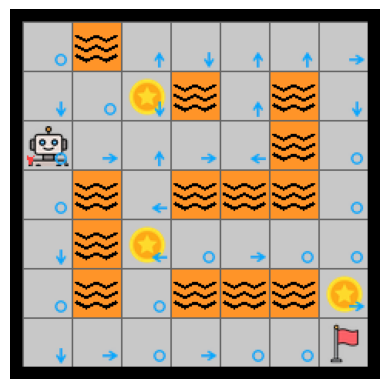

In [20]:
show_obs(windy_env.render(action_todo=1, show_policy=True, show_wind=True))

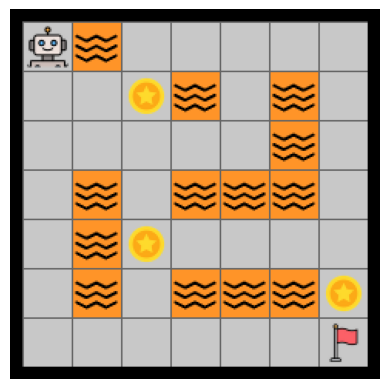

In [21]:
show_obs(windy_env.render_map(mappings={s:1 for s in np.ndindex(*windy_env.state_space)}))

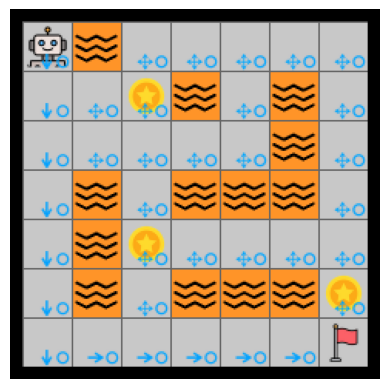

In [22]:
show_obs(windy_env.render_map(mappings={s:1 for s in np.ndindex(*windy_env.state_space)}, draw_wind=True))

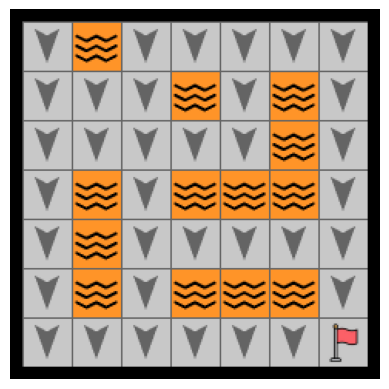

In [23]:
show_obs(windy_env.render_map(mappings={s:1 for s in np.ndindex(*windy_env.state_space)}, draw_wind=False, draw_policy=True))

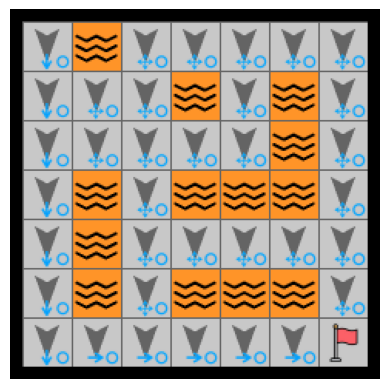

In [24]:
show_obs(windy_env.render_map(mappings={s:1 for s in np.ndindex(*windy_env.state_space)}, draw_wind=True, draw_policy=True))

### LavaCross Animation Example

In [25]:
import numpy as np
import gymnasium as gym
import causal_gym as cgym
import matplotlib.pyplot as plt

def display_frames(frames, figsize=(10, 8)):
    """Displays a list of frames (RGB arrays) as an animation or sequence."""
    if not frames:
        print("No frames to display.")
        return
    
    # Check if frames are Pygame surfaces or numpy arrays
    if isinstance(frames[0], np.ndarray):
        # Simple display for a few frames, or animate if many
        if len(frames) <= 5:
            fig, axes = plt.subplots(1, len(frames), figsize=figsize)
            if len(frames) == 1:
                axes = [axes] # make it iterable
            for i, frame in enumerate(frames):
                axes[i].imshow(frame)
                axes[i].axis('off')
            plt.tight_layout()
            plt.show()
        else: # Animation for many frames
            fig = plt.figure(figsize=figsize)
            plt.axis('off')
            plt.tight_layout()
            img_display = plt.imshow(frames[0])
            def animate(i):
                img_display.set_data(frames[i])
                return [img_display]
            
            from matplotlib.animation import FuncAnimation
            anim = FuncAnimation(fig, animate, frames=len(frames), interval=50, blit=True)
            from IPython.display import HTML
            plt.close(fig) # close the static plot
            display(HTML(anim.to_jshtml()))
            print("Displaying animation.")

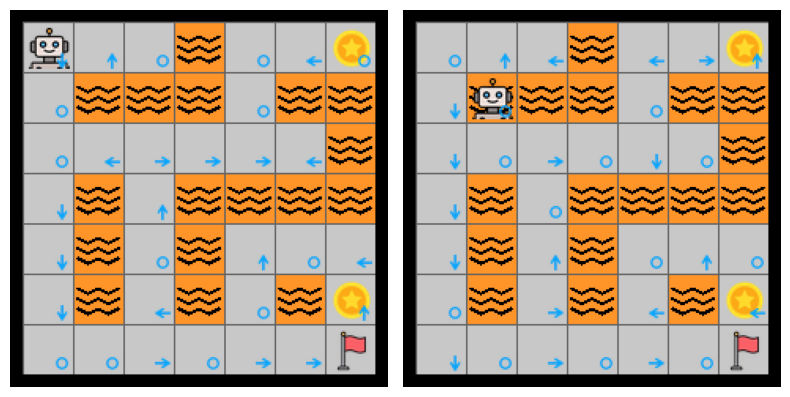

In [27]:
env = gym.make('Custom-LavaCrossing-maze-v0', max_episode_steps=70, agent_pov=False, render_mode='rgb_array', highlight=False, size=9)
windy_env = MiniGridActionRemapWrapper(WindyMiniGridPCH(env=env, show_wind=True, wind_dist=WIND_DIST['Custom-LavaCrossing-maze-v0']))
init_obs, info = windy_env.reset(seed=SEED)
frames = []
frames.append(windy_env.render())
for _ in range(30):
    obs, reward, done, truncated, info = windy_env.do(lambda x: windy_env.action_space.sample())
    frames.append(windy_env.render())
    if done or truncated:
        break
display_frames(frames, figsize=(8, 6))